# 🛡️ Theft & Shoplifting Detection — Deep Learning

**Module Deep Learning | Encadrant : M. Abdallah Khemais**

---

### 🎯 Objectif
Classifier automatiquement des images de vidéosurveillance :
- 🔴 `theft` — vol détecté
- 🟢 `normal` — comportement normal

### 🗺️ Plan
| # | Section |
|---|---------|
| 1 | Setup & Configuration |
| 2 | Conversion YOLO → ImageFolder |
| 3 | Datasets & DataLoaders (P4 Balance) |
| 4 | Exploration des Données |
| 5 | Fonctions Utilitaires |
| 6 | Architectures des Modèles |
| 7 | Baseline CNN |
| 8 | ResNet-50 |
| 9 | EfficientNet-B0 |
| 10 | MobileNetV3-Small |
| 11 | VGG-16 |
| 12 | P5 Fine-Tuning Progressif |
| 13 | Comparaison Finale |

---
## 1. ⚙️ Setup & Configuration

In [1]:
import os, shutil, time, copy, gc
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

BASE_DIR      = Path('/kaggle/input/datasets/raniadabbek/projet-dl/deep_learning')
OUTPUT_DIR    = Path('/kaggle/working/deep_learning_clf')
TRAIN_DIR     = OUTPUT_DIR / 'train'
VAL_DIR       = OUTPUT_DIR / 'valid'
TEST_DIR      = OUTPUT_DIR / 'test'
MODELS_DIR    = Path('/kaggle/working/models')
MODELS_DIR.mkdir(exist_ok=True)

CLASS_NAMES   = ['normal', 'theft']
NUM_CLASSES   = 2
IMG_SIZE      = 224
BATCH_SIZE    = 16
NUM_EPOCHS    = 10
MAX_PER_CLASS = 1500
NUM_WORKERS   = 2
ID_IS_THEFT   = {0: False, 1: True, 2: True, 3: True}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Désactiver timer auto
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.events.callbacks.get('pre_run_cell',  []).clear()
    ip.events.callbacks.get('post_run_cell', []).clear()

def timer_start(): return time.time()
def timer_end(t0, label=''):
    m, s = divmod(time.time()-t0, 60)
    print(f'⏱️  {label} : {int(m)}m {s:.2f}s')

print(f'✅ Setup OK — device={device}  cpu={os.cpu_count()}')

✅ Setup OK — device=cuda  cpu=4


---
## 2. 📂 Conversion YOLO → ImageFolder

In [2]:
t0 = timer_start()

def classify_image(lbl_path):
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        return 'normal'
    with open(lbl_path) as f:
        lines = [l.strip() for l in f if l.strip()]
    if not lines: return 'normal'
    theft  = sum(1 for l in lines if ID_IS_THEFT.get(int(l.split()[0]), False))
    return 'theft' if theft > (len(lines) - theft) else 'normal'

def yolo_to_imagefolder(base_dir, output_dir):
    if output_dir.exists(): shutil.rmtree(output_dir)
    stats = {}
    for split in ['train', 'valid', 'test']:
        img_dir = base_dir / split / 'images'
        lbl_dir = base_dir / split / 'labels'
        if not img_dir.exists(): continue
        counter = Counter()
        for img_path in sorted(img_dir.iterdir()):
            if img_path.suffix.lower() not in {'.jpg','.jpeg','.png','.bmp','.webp'}: continue
            lbl_path   = lbl_dir / (img_path.stem + '.txt')
            class_name = classify_image(lbl_path)
            dest = output_dir / split / class_name
            dest.mkdir(parents=True, exist_ok=True)
            shutil.copy2(img_path, dest / img_path.name)
            counter[class_name] += 1
        stats[split] = counter
    return stats

print('🔄 Conversion en cours (~3-5 min) ...')
stats = yolo_to_imagefolder(BASE_DIR, OUTPUT_DIR)
for split, c in stats.items():
    total = sum(c.values())
    print(f'  [{split}]  ' + '  '.join(f'{k}:{v}' for k,v in c.items()) + f'  TOTAL:{total}')

timer_end(t0, 'Conversion')

🔄 Conversion en cours (~3-5 min) ...
  [train]  normal:2384  theft:6387  TOTAL:8771
  [valid]  theft:545  normal:55  TOTAL:600
  [test]  normal:136  theft:240  TOTAL:376
⏱️  Conversion : 2m 40.46s


---
## 3. 🗃️ Datasets & DataLoaders — P4 Balance (Class Weights)

In [ ]:
t0 = timer_start()

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds     = datasets.ImageFolder(VAL_DIR,   transform=val_transform)
test_ds    = datasets.ImageFolder(TEST_DIR,  transform=val_transform)

indices, class_counts = [], Counter()
for idx, label in enumerate(full_train.targets):
    if class_counts[label] < MAX_PER_CLASS:
        indices.append(idx)
        class_counts[label] += 1
train_ds = Subset(full_train, indices)

subset_labels = [full_train.targets[i] for i in indices]
counts_tr     = Counter(subset_labels)
class_weights = torch.tensor(
    [len(subset_labels)/(NUM_CLASSES * counts_tr[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
)
sample_w = torch.tensor([class_weights[l] for l in subset_labels])
sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

crit_weighted = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=0.1)

print(f'✅ Train  : {len(train_ds):,}  {dict(class_counts)}')
print(f'✅ Valid  : {len(val_ds):,}')
print(f'✅ Test   : {len(test_ds):,}')
print(f'⚖️  Weights: {dict(zip(CLASS_NAMES, class_weights.numpy().round(3)))}')

timer_end(t0, 'Datasets')

✅ Train  : 3,000  {0: 1500, 1: 1500}
✅ Valid  : 600
✅ Test   : 376
⚖️  Weights: {'normal': np.float32(1.0), 'theft': np.float32(1.0)}
⏱️  Datasets : 0m 0.37s


---
## 4. 🔍 Exploration des Données

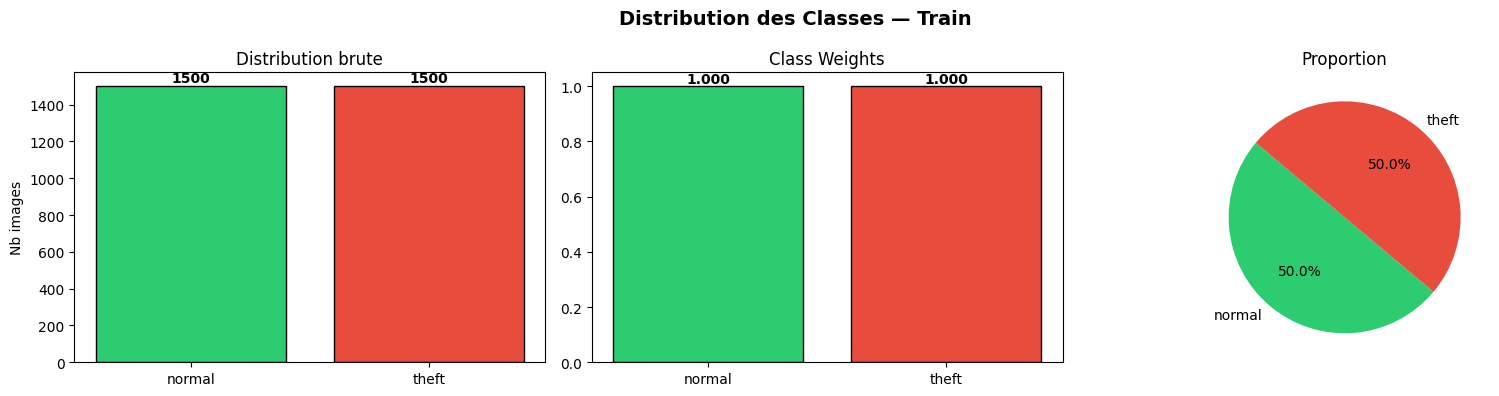

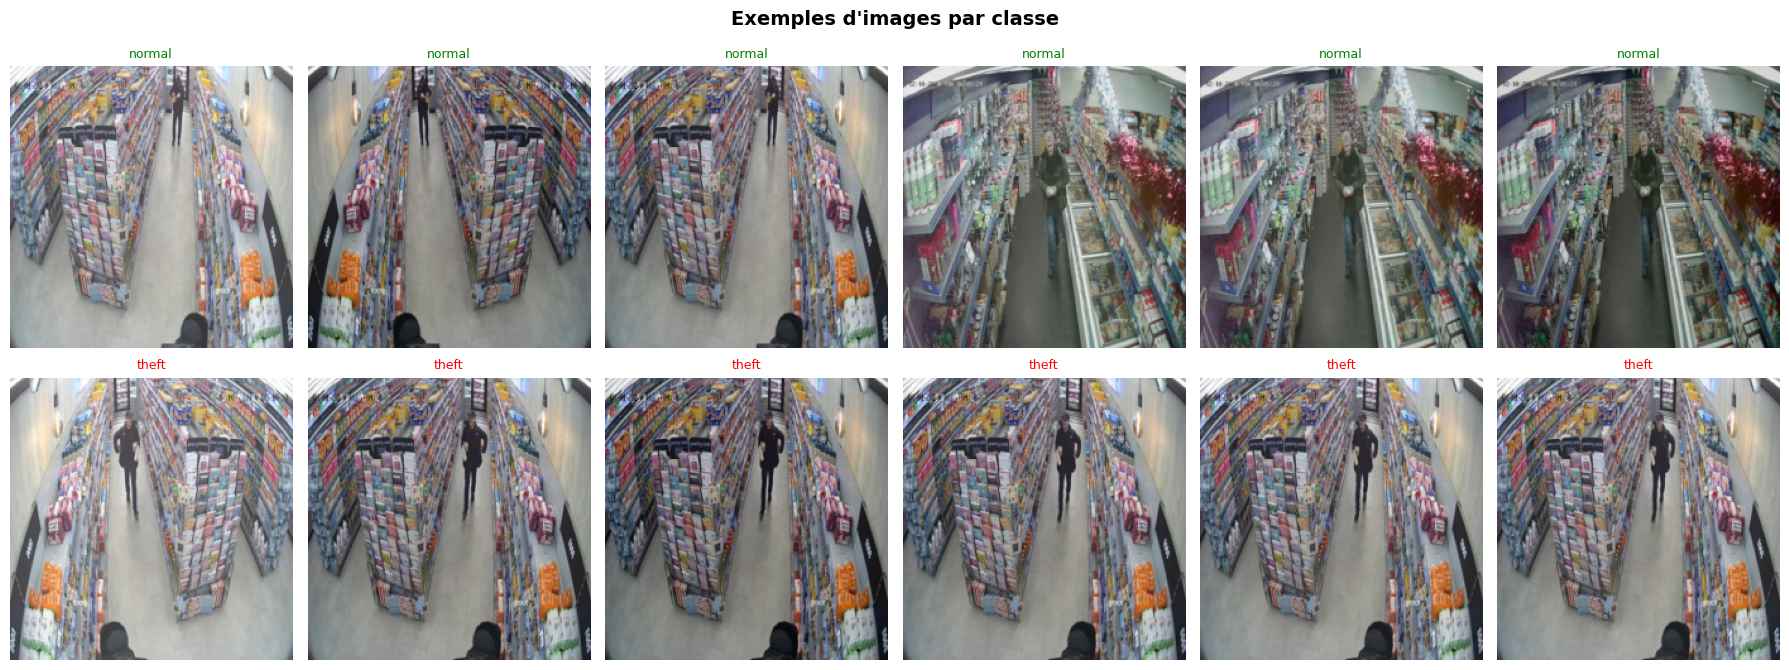

In [ ]:
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.numpy().transpose((1, 2, 0))
    return np.clip(std * img + mean, 0, 1)


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribution des Classes — Train', fontsize=14, fontweight='bold')

colors    = ['#2ECC71', '#E74C3C']
counts_v  = [counts_tr[i] for i in range(NUM_CLASSES)]
w_vals    = [class_weights[i].item() for i in range(NUM_CLASSES)]

bars = axes[0].bar(CLASS_NAMES, counts_v, color=colors, edgecolor='black')
for bar, v in zip(bars, counts_v):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+20, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribution brute'); axes[0].set_ylabel("Nb images")

bars2 = axes[1].bar(CLASS_NAMES, w_vals, color=colors, edgecolor='black')
for bar, w in zip(bars2, w_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, w+0.01, f'{w:.3f}', ha='center', fontweight='bold')
axes[1].set_title('Class Weights')

axes[2].pie(counts_v, labels=CLASS_NAMES, colors=colors, autopct='%1.1f%%', startangle=140)
axes[2].set_title('Proportion')
plt.tight_layout(); plt.show()


basic_tf     = transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)), transforms.ToTensor(),
                                    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
preview_full = datasets.ImageFolder(TRAIN_DIR, transform=basic_tf)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle("Exemples d'images par classe", fontsize=14, fontweight='bold')
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    idxs = [i for i, (_, l) in enumerate(preview_full.samples) if l == cls_idx][:6]
    for col, idx in enumerate(idxs):
        img, _ = preview_full[idx]
        axes[cls_idx][col].imshow(denormalize(img))
        axes[cls_idx][col].set_title(cls_name, fontsize=9,
            color='green' if cls_name=='normal' else 'red')
        axes[cls_idx][col].axis('off')
plt.tight_layout(); plt.show()

---
## 5. 🛠️ Fonctions Utilitaires

In [ ]:
t0 = timer_start()


def train_model(model, criterion, optimizer, scheduler=None,
                num_epochs=NUM_EPOCHS, label='model'):
    history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best_acc, best_w = 0.0, copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        ep_t0 = time.time()
        # Train
        model.train()
        tr_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)
        tr_loss /= total; tr_acc = correct / total
        # Val
        model.eval()
        vl_loss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out      = model(imgs)
                loss     = criterion(out, labels)
                vl_loss += loss.item() * imgs.size(0)
                vc      += (out.argmax(1) == labels).sum().item()
                vt      += labels.size(0)
        vl_loss /= vt; vl_acc = vc / vt
        if scheduler: scheduler.step()
        if vl_acc > best_acc:
            best_acc = vl_acc
            best_w   = copy.deepcopy(model.state_dict())
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        ep_elapsed = time.time() - ep_t0
        ep_m, ep_s = divmod(ep_elapsed, 60)
        print(f'[{label}] {epoch+1:02d}/{num_epochs} | '
              f'Loss {tr_loss:.3f}/{vl_loss:.3f} | '
              f'Acc {tr_acc:.3f}/{vl_acc:.3f} | '
              f'Best {best_acc:.3f} | '
              f'{int(ep_m)}m {ep_s:.1f}s')
        torch.cuda.empty_cache(); gc.collect()

    model.load_state_dict(best_w)
    return model, history


def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, (tr_k, vl_k), name in zip(axes,
            [('train_loss','val_loss'),('train_acc','val_acc')], ['Loss','Accuracy']):
        ax.plot(history[tr_k], label='Train', marker='o', markersize=3)
        ax.plot(history[vl_k], label='Val',   marker='o', markersize=3)
        ax.set_title(name); ax.legend(); ax.grid(alpha=0.3)
        if name == 'Accuracy': ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()


def evaluate_model(model, loader, label=''):
    model.eval()
    preds, labs, loss_sum, total = [], [], 0.0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out       = model(imgs)
            loss_sum += crit_weighted(out, labels).item() * imgs.size(0)
            preds    .extend(out.argmax(1).cpu().numpy())
            labs     .extend(labels.cpu().numpy())
            total    += labels.size(0)
    acc = sum(p==l for p,l in zip(preds,labs)) / total
    print(f'\n[{label}] Test Acc={acc:.4f}  Loss={loss_sum/total:.4f}')
    print(classification_report(labs, preds, target_names=CLASS_NAMES))
    cm = confusion_matrix(labs, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {label}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()
    return {'label': label, 'acc': acc, 'loss': loss_sum/total,
            'preds': np.array(preds), 'labels': np.array(labs)}


def save_model(model, name, history):
    path = MODELS_DIR / f'{name}.pth'
    torch.save({'state_dict':    model.state_dict(),
                'class_names':   CLASS_NAMES,
                'best_val_acc':  max(history['val_acc'])}, path)
    print(f'Modele sauvegarde : {path}  (val_acc={max(history["val_acc"]):.4f})')


all_models    = {}
all_histories = {}
all_results   = {}

print('Fonctions OK : train_model / plot_history / evaluate_model / save_model')

timer_end(t0, 'Fonctions utilitaires')

Fonctions OK : train_model / plot_history / evaluate_model / save_model
⏱️  Fonctions utilitaires : 0m 0.00s


---
## 6. 🏗️ Architectures des Modèles

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(512, 128),     nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))


def make_model(arch, freeze=True):
    if arch == 'resnet50':
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        if freeze:
            for p in m.parameters(): p.requires_grad = False
        m.fc = nn.Sequential(
            nn.Linear(m.fc.in_features, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, NUM_CLASSES)
        )
    elif arch == 'efficientnet_b0':
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze:
            for p in m.parameters(): p.requires_grad = False
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(in_f, 128),
            nn.ReLU(),       nn.Dropout(0.3), nn.Linear(128, NUM_CLASSES)
        )
    elif arch == 'mobilenet_v3_small':
        m = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        if freeze:
            for p in m.parameters(): p.requires_grad = False
        in_f = m.classifier[3].in_features
        m.classifier[3] = nn.Sequential(
            nn.Linear(in_f, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, NUM_CLASSES)
        )
    elif arch == 'vgg16':
        m = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        if freeze:
            for p in m.features.parameters(): p.requires_grad = False
        in_f = m.classifier[6].in_features
        m.classifier[6] = nn.Sequential(
            nn.Linear(in_f, 128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, NUM_CLASSES)
        )
    else:
        raise ValueError(f'Architecture inconnue : {arch}')
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  [{arch}] Total={total:,}  Trainable={trainable:,} ({100*trainable/total:.1f}%)')
    return m.to(device)

print('Architectures definies : SimpleCNN + ResNet50 + EfficientNet-B0 + MobileNetV3 + VGG16')

Architectures definies : SimpleCNN + ResNet50 + EfficientNet-B0 + MobileNetV3 + VGG16


In [ ]:
import os
from pathlib import Path

MODELS_DIR = Path('/kaggle/working/models')
MODELS_DIR.mkdir(exist_ok=True)

# Vérifier l'espace disponible
total, used, free = shutil.disk_usage('/kaggle/working/')
print(f'💾 Espace disponible : {free/1e9:.1f} GB / {total/1e9:.1f} GB')
print(f'📁 Dossier modèles  : {MODELS_DIR}')
print('✅ Prêt pour l\'entraînement\n')
print('⚠️  IMPORTANT : après l\'entraînement')
print('   → Cliquez "Save Version" → "Save and Run All"')
print('   → Les modèles seront sauvegardés dans Output')
print('   → Téléchargeables depuis la page du notebook')

💾 Espace disponible : 19.8 GB / 21.0 GB
📁 Dossier modèles  : /kaggle/working/models
✅ Prêt pour l'entraînement

⚠️  IMPORTANT : après l'entraînement
   → Cliquez "Save Version" → "Save and Run All"
   → Les modèles seront sauvegardés dans Output
   → Téléchargeables depuis la page du notebook


---
## 7. 🟢 Baseline CNN (from scratch)

  Modele : Baseline CNN (from scratch)
  Params : 2,552,962

[Baseline-CNN] 01/10 | Loss 0.411/0.629 | Acc 0.893/0.722 | Best 0.722 | 0m 17.9s
[Baseline-CNN] 02/10 | Loss 0.342/0.596 | Acc 0.926/0.803 | Best 0.803 | 0m 16.4s
[Baseline-CNN] 03/10 | Loss 0.332/0.751 | Acc 0.925/0.695 | Best 0.803 | 0m 16.2s
[Baseline-CNN] 04/10 | Loss 0.312/0.715 | Acc 0.938/0.723 | Best 0.803 | 0m 16.6s
[Baseline-CNN] 05/10 | Loss 0.307/0.600 | Acc 0.943/0.752 | Best 0.803 | 0m 16.5s
[Baseline-CNN] 06/10 | Loss 0.302/0.623 | Acc 0.948/0.733 | Best 0.803 | 0m 16.6s
[Baseline-CNN] 07/10 | Loss 0.293/0.807 | Acc 0.952/0.662 | Best 0.803 | 0m 16.2s
[Baseline-CNN] 08/10 | Loss 0.295/0.873 | Acc 0.948/0.670 | Best 0.803 | 0m 16.6s
[Baseline-CNN] 09/10 | Loss 0.283/0.795 | Acc 0.958/0.707 | Best 0.803 | 0m 16.8s
[Baseline-CNN] 10/10 | Loss 0.275/0.789 | Acc 0.959/0.717 | Best 0.803 | 0m 16.6s


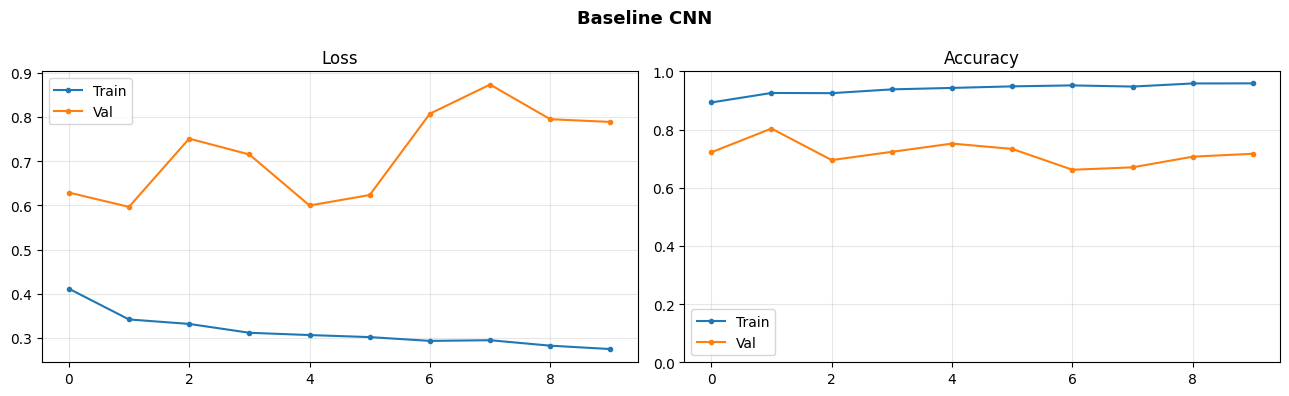


[Baseline-CNN] Test Acc=0.5718  Loss=1.1637
              precision    recall  f1-score   support

      normal       0.45      0.90      0.60       136
       theft       0.88      0.38      0.53       240

    accuracy                           0.57       376
   macro avg       0.67      0.64      0.57       376
weighted avg       0.72      0.57      0.56       376



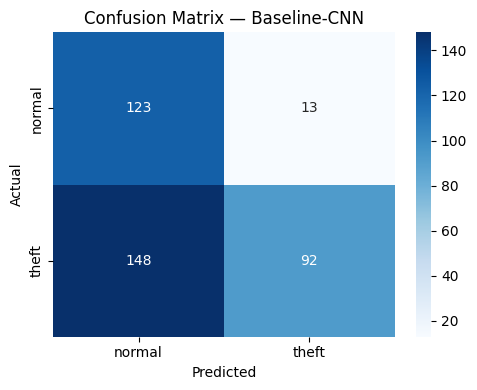

Modele sauvegarde : /kaggle/working/models/baseline_cnn.pth  (val_acc=0.8033)


10966

In [8]:
print('=' * 55)
print('  Modele : Baseline CNN (from scratch)')
print('=' * 55)

baseline = SimpleCNN().to(device)
total    = sum(p.numel() for p in baseline.parameters())
print(f'  Params : {total:,}\n')

opt_b = optim.Adam(baseline.parameters(), lr=1e-3)
sch_b = optim.lr_scheduler.StepLR(opt_b, step_size=3, gamma=0.5)

baseline, hist_baseline = train_model(
    baseline, crit_weighted, opt_b, sch_b, label='Baseline-CNN'
)

plot_history(hist_baseline, 'Baseline CNN')
result_baseline = evaluate_model(baseline, test_loader, label='Baseline-CNN')
save_model(baseline, 'baseline_cnn', hist_baseline)

all_models['Baseline-CNN']    = baseline
all_histories['Baseline-CNN'] = hist_baseline
all_results['Baseline-CNN']   = result_baseline

torch.cuda.empty_cache(); gc.collect()

---
## 8. 🔵 ResNet-50 (Transfer Learning)

  Modele : ResNet-50 (backbone gele)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


  [resnet50] Total=23,770,562  Trainable=262,530 (1.1%)
[ResNet-50] 01/10 | Loss 0.433/0.436 | Acc 0.874/0.883 | Best 0.883 | 0m 17.8s
[ResNet-50] 02/10 | Loss 0.387/0.571 | Acc 0.902/0.807 | Best 0.883 | 0m 17.0s
[ResNet-50] 03/10 | Loss 0.356/0.519 | Acc 0.916/0.855 | Best 0.883 | 0m 16.8s
[ResNet-50] 04/10 | Loss 0.345/0.491 | Acc 0.923/0.862 | Best 0.883 | 0m 17.2s
[ResNet-50] 05/10 | Loss 0.341/0.470 | Acc 0.921/0.872 | Best 0.883 | 0m 17.1s
[ResNet-50] 06/10 | Loss 0.330/0.429 | Acc 0.930/0.883 | Best 0.883 | 0m 17.4s
[ResNet-50] 07/10 | Loss 0.334/0.518 | Acc 0.927/0.842 | Best 0.883 | 0m 17.4s
[ResNet-50] 08/10 | Loss 0.320/0.472 | Acc 0.932/0.865 | Best 0.883 | 0m 17.0s
[ResNet-50] 09/10 | Loss 0.313/0.458 | Acc 0.938/0.870 | Best 0.883 | 0m 17.2s
[ResNet-50] 10/10 | Loss 0.323/0.482 | Acc 0.933/0.863 | Best 0.883 | 0m 17.1s


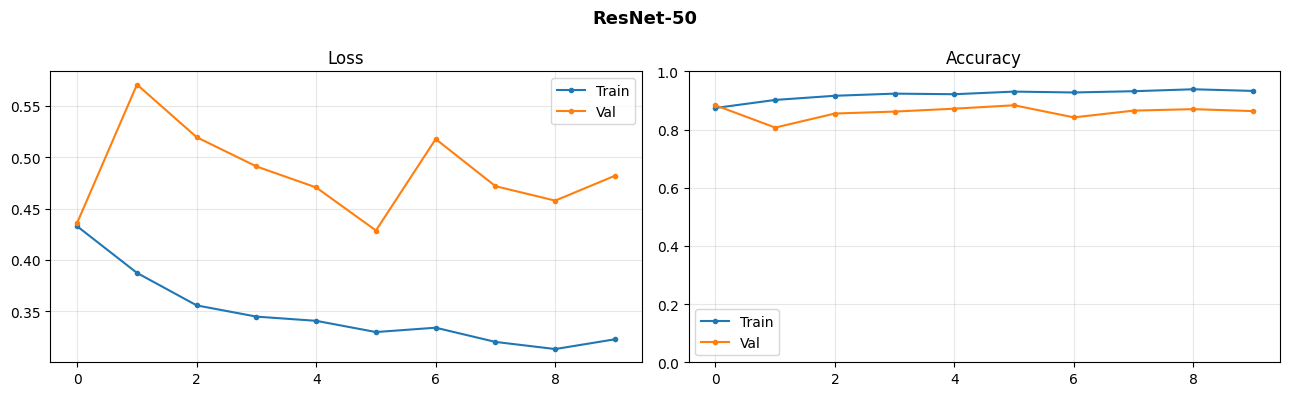


[ResNet-50] Test Acc=0.5904  Loss=0.7215
              precision    recall  f1-score   support

      normal       0.47      0.93      0.62       136
       theft       0.91      0.40      0.55       240

    accuracy                           0.59       376
   macro avg       0.69      0.66      0.59       376
weighted avg       0.75      0.59      0.58       376



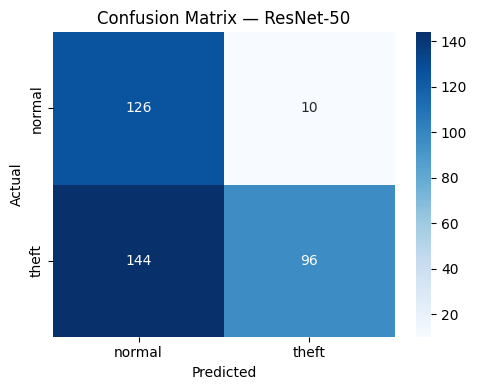

Modele sauvegarde : /kaggle/working/models/resnet50.pth  (val_acc=0.8833)


10693

In [9]:
print('=' * 55)
print('  Modele : ResNet-50 (backbone gele)')
print('=' * 55)

resnet = make_model('resnet50', freeze=True)

opt_r = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr=3e-4
)
sch_r = optim.lr_scheduler.StepLR(opt_r, step_size=3, gamma=0.5)

resnet, hist_resnet = train_model(
    resnet, crit_weighted, opt_r, sch_r, label='ResNet-50'
)

plot_history(hist_resnet, 'ResNet-50')
result_resnet = evaluate_model(resnet, test_loader, label='ResNet-50')
save_model(resnet, 'resnet50', hist_resnet)

all_models['ResNet-50']    = resnet
all_histories['ResNet-50'] = hist_resnet
all_results['ResNet-50']   = result_resnet

torch.cuda.empty_cache(); gc.collect()

---
## 9. 🟣 EfficientNet-B0 (Transfer Learning)

  Modele : EfficientNet-B0 (backbone gele)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


  [efficientnet_b0] Total=4,171,774  Trainable=164,226 (3.9%)
[EfficientNet-B0] 01/10 | Loss 0.400/0.863 | Acc 0.894/0.275 | Best 0.275 | 0m 16.2s
[EfficientNet-B0] 02/10 | Loss 0.365/0.730 | Acc 0.905/0.487 | Best 0.487 | 0m 16.2s
[EfficientNet-B0] 03/10 | Loss 0.341/0.642 | Acc 0.915/0.635 | Best 0.635 | 0m 16.2s
[EfficientNet-B0] 04/10 | Loss 0.329/0.699 | Acc 0.930/0.557 | Best 0.635 | 0m 15.8s
[EfficientNet-B0] 05/10 | Loss 0.332/0.701 | Acc 0.927/0.568 | Best 0.635 | 0m 16.2s
[EfficientNet-B0] 06/10 | Loss 0.315/0.691 | Acc 0.933/0.610 | Best 0.635 | 0m 16.2s
[EfficientNet-B0] 07/10 | Loss 0.318/0.675 | Acc 0.934/0.638 | Best 0.638 | 0m 16.1s
[EfficientNet-B0] 08/10 | Loss 0.320/0.659 | Acc 0.924/0.643 | Best 0.643 | 0m 16.3s
[EfficientNet-B0] 09/10 | Loss 0.320/0.694 | Acc 0.933/0.610 | Best 0.643 | 0m 15.8s
[EfficientNet-B0] 10/10 | Loss 0.315/0.629 | Acc 0.934/0.685 | Best 0.685 | 0m 15.8s


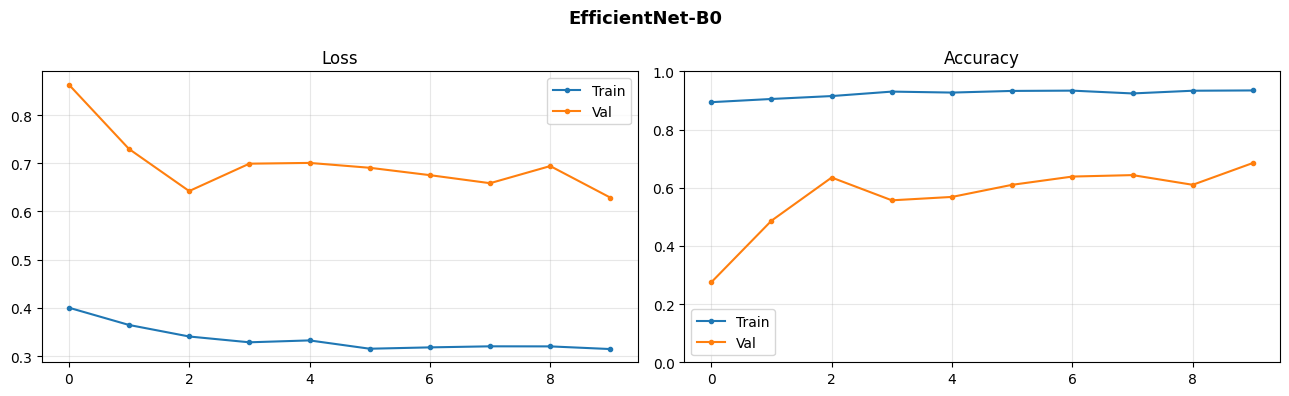


[EfficientNet-B0] Test Acc=0.5878  Loss=1.1601
              precision    recall  f1-score   support

      normal       0.47      0.94      0.62       136
       theft       0.92      0.39      0.55       240

    accuracy                           0.59       376
   macro avg       0.69      0.66      0.58       376
weighted avg       0.76      0.59      0.57       376



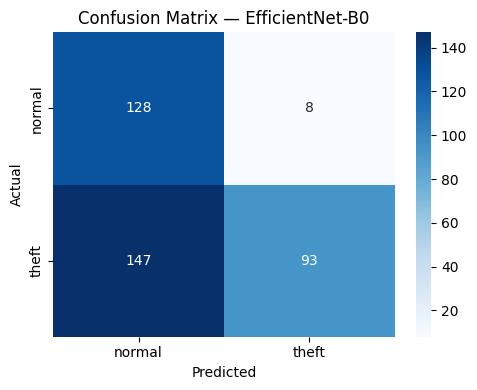

Modele sauvegarde : /kaggle/working/models/efficientnet_b0.pth  (val_acc=0.6850)


6328

In [10]:
print('=' * 55)
print('  Modele : EfficientNet-B0 (backbone gele)')
print('=' * 55)

effnet = make_model('efficientnet_b0', freeze=True)

opt_e = optim.Adam(
    filter(lambda p: p.requires_grad, effnet.parameters()), lr=3e-4
)
sch_e = optim.lr_scheduler.StepLR(opt_e, step_size=3, gamma=0.5)

effnet, hist_effnet = train_model(
    effnet, crit_weighted, opt_e, sch_e, label='EfficientNet-B0'
)

plot_history(hist_effnet, 'EfficientNet-B0')
result_effnet = evaluate_model(effnet, test_loader, label='EfficientNet-B0')
save_model(effnet, 'efficientnet_b0', hist_effnet)

all_models['EfficientNet-B0']    = effnet
all_histories['EfficientNet-B0'] = hist_effnet
all_results['EfficientNet-B0']   = result_effnet

torch.cuda.empty_cache(); gc.collect()

---
## 10. 🟠 MobileNetV3-Small (Transfer Learning)

  Modele : MobileNetV3-Small (backbone gele)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 129MB/s]

  [mobilenet_v3_small] Total=1,649,314  Trainable=131,458 (8.0%)


[MobileNetV3] 01/10 | Loss 0.374/0.595 | Acc 0.909/0.778 | Best 0.778 | 0m 15.4s
[MobileNetV3] 02/10 | Loss 0.312/0.550 | Acc 0.934/0.822 | Best 0.822 | 0m 15.8s
[MobileNetV3] 03/10 | Loss 0.307/0.595 | Acc 0.943/0.765 | Best 0.822 | 0m 15.6s
[MobileNetV3] 04/10 | Loss 0.287/0.617 | Acc 0.954/0.725 | Best 0.822 | 0m 15.6s
[MobileNetV3] 05/10 | Loss 0.287/0.596 | Acc 0.954/0.773 | Best 0.822 | 0m 15.8s
[MobileNetV3] 06/10 | Loss 0.278/0.642 | Acc 0.963/0.665 | Best 0.822 | 0m 15.5s
[MobileNetV3] 07/10 | Loss 0.287/0.627 | Acc 0.953/0.717 | Best 0.822 | 0m 15.3s
[MobileNetV3] 08/10 | Loss 0.283/0.607 | Acc 0.959/0.752 | Best 0.822 | 0m 15.4s
[MobileNetV3] 09/10 | Loss 0.285/0.633 | Acc 0.956/0.720 | Best 0.822 | 0m 15.6s
[MobileNetV3] 10/10 | Loss 0.272/0.632 | Acc 0.966/0.713 | Best 0.822 | 0m 15.4s


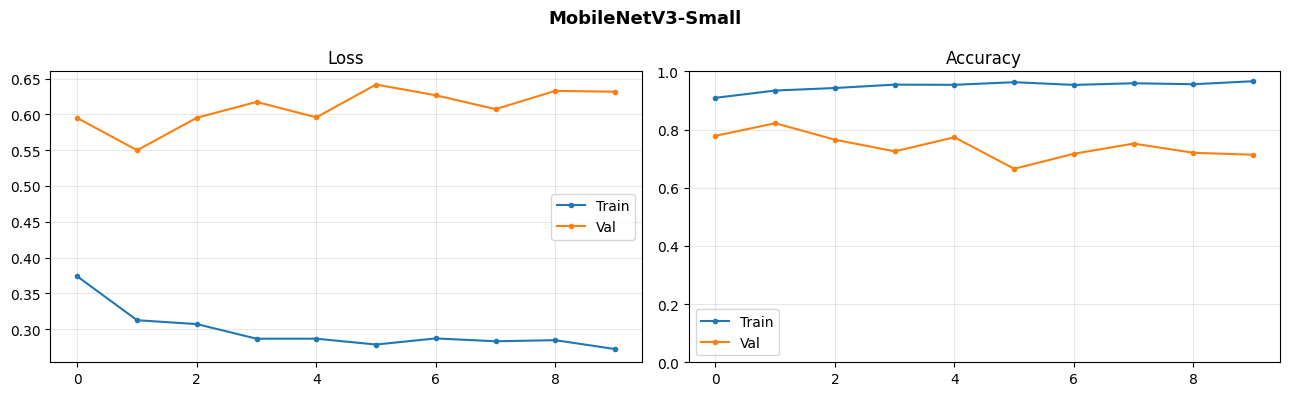


[MobileNetV3] Test Acc=0.5824  Loss=0.7283
              precision    recall  f1-score   support

      normal       0.46      0.90      0.61       136
       theft       0.88      0.40      0.55       240

    accuracy                           0.58       376
   macro avg       0.67      0.65      0.58       376
weighted avg       0.73      0.58      0.57       376



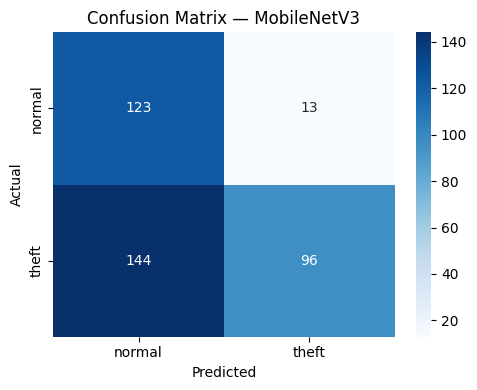

Modele sauvegarde : /kaggle/working/models/mobilenet_v3.pth  (val_acc=0.8217)


11020

In [11]:
print('=' * 55)
print('  Modele : MobileNetV3-Small (backbone gele)')
print('=' * 55)

mobilenet = make_model('mobilenet_v3_small', freeze=True)

opt_m = optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()), lr=3e-4
)
sch_m = optim.lr_scheduler.StepLR(opt_m, step_size=3, gamma=0.5)

mobilenet, hist_mobilenet = train_model(
    mobilenet, crit_weighted, opt_m, sch_m, label='MobileNetV3'
)

plot_history(hist_mobilenet, 'MobileNetV3-Small')
result_mobilenet = evaluate_model(mobilenet, test_loader, label='MobileNetV3')
save_model(mobilenet, 'mobilenet_v3', hist_mobilenet)

all_models['MobileNetV3']    = mobilenet
all_histories['MobileNetV3'] = hist_mobilenet
all_results['MobileNetV3']   = result_mobilenet

torch.cuda.empty_cache(); gc.collect()

---
## 11. 🔴 VGG-16 (Transfer Learning)

  Modele : VGG-16 (features gelees)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 188MB/s]


  [vgg16] Total=134,785,218  Trainable=120,070,530 (89.1%)
[VGG-16] 01/10 | Loss 0.369/0.425 | Acc 0.914/0.905 | Best 0.905 | 0m 25.6s
[VGG-16] 02/10 | Loss 0.321/0.410 | Acc 0.936/0.908 | Best 0.908 | 0m 25.7s
[VGG-16] 03/10 | Loss 0.303/0.401 | Acc 0.947/0.902 | Best 0.908 | 0m 25.3s
[VGG-16] 04/10 | Loss 0.272/0.396 | Acc 0.963/0.908 | Best 0.908 | 0m 25.5s
[VGG-16] 05/10 | Loss 0.273/0.389 | Acc 0.963/0.908 | Best 0.908 | 0m 25.6s
[VGG-16] 06/10 | Loss 0.268/0.391 | Acc 0.966/0.908 | Best 0.908 | 0m 25.4s
[VGG-16] 07/10 | Loss 0.253/0.393 | Acc 0.976/0.908 | Best 0.908 | 0m 25.4s
[VGG-16] 08/10 | Loss 0.257/0.392 | Acc 0.969/0.908 | Best 0.908 | 0m 25.5s
[VGG-16] 09/10 | Loss 0.258/0.384 | Acc 0.970/0.908 | Best 0.908 | 0m 25.5s
[VGG-16] 10/10 | Loss 0.249/0.388 | Acc 0.977/0.908 | Best 0.908 | 0m 25.4s


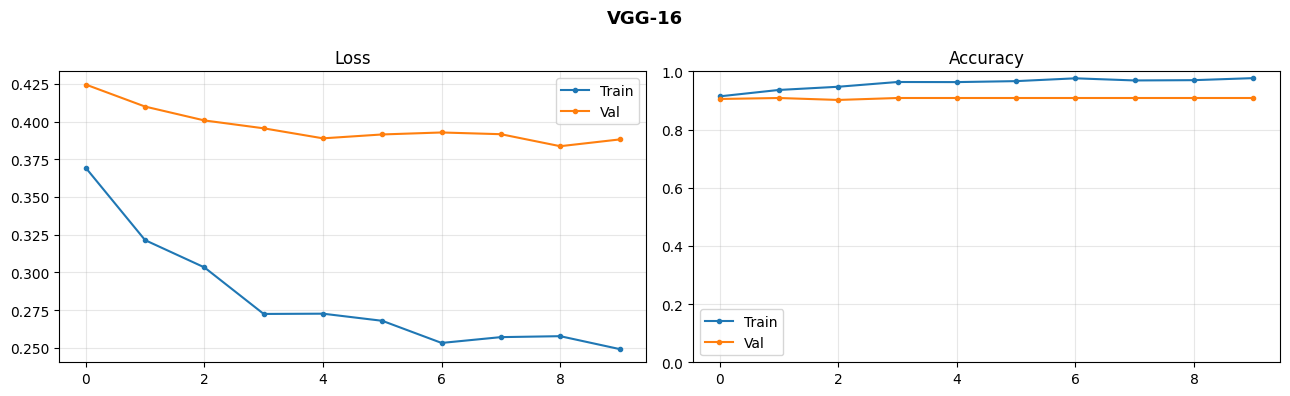


[VGG-16] Test Acc=0.5665  Loss=1.1150
              precision    recall  f1-score   support

      normal       0.45      0.93      0.61       136
       theft       0.91      0.36      0.51       240

    accuracy                           0.57       376
   macro avg       0.68      0.65      0.56       376
weighted avg       0.74      0.57      0.55       376



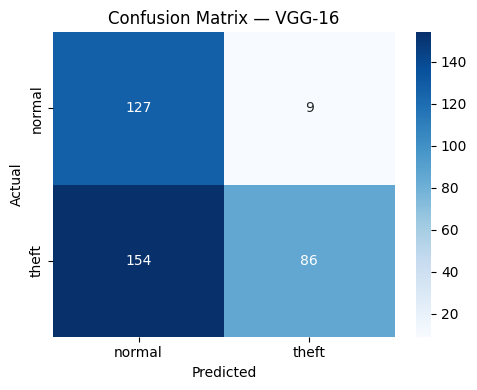

Modele sauvegarde : /kaggle/working/models/vgg16.pth  (val_acc=0.9083)


11067

In [12]:
print('=' * 55)
print('  Modele : VGG-16 (features gelees)')
print('=' * 55)

vgg = make_model('vgg16', freeze=True)

opt_v = optim.Adam(
    filter(lambda p: p.requires_grad, vgg.parameters()), lr=1e-4
)
sch_v = optim.lr_scheduler.StepLR(opt_v, step_size=3, gamma=0.5)

vgg, hist_vgg = train_model(
    vgg, crit_weighted, opt_v, sch_v, label='VGG-16'
)

plot_history(hist_vgg, 'VGG-16')
result_vgg = evaluate_model(vgg, test_loader, label='VGG-16')
save_model(vgg, 'vgg16', hist_vgg)

all_models['VGG-16']    = vgg
all_histories['VGG-16'] = hist_vgg
all_results['VGG-16']   = result_vgg

torch.cuda.empty_cache(); gc.collect()

---
## 12. 🔬 P5 — Fine-Tuning Progressif (meilleur modèle TL)

Meilleur modele TL : ResNet-50  (test acc=0.5904)
Progressive unfreeze sur : ResNet-50

  [resnet50] Total=23,770,562  Trainable=262,530 (1.1%)

  PHASE 1 — Head uniquement (backbone gele)
  Trainable : 3,675,522 / 23,770,562 (15.5%)
  [Phase1] 01/4 | Loss 0.367/0.505 | Acc 0.910/0.832 | Best 0.832 | 17.4s
  [Phase1] 02/4 | Loss 0.300/0.467 | Acc 0.949/0.818 | Best 0.832 | 17.3s
  [Phase1] 03/4 | Loss 0.297/0.547 | Acc 0.951/0.817 | Best 0.832 | 17.3s
  [Phase1] 04/4 | Loss 0.275/0.539 | Acc 0.963/0.797 | Best 0.832 | 17.5s

  PHASE 2 — Derniers blocs (unfreeze partiel)
  Trainable : 17,199,234 / 23,770,562 (72.4%)
  [Phase2] 01/4 | Loss 0.288/0.419 | Acc 0.954/0.895 | Best 0.895 | 19.3s
  [Phase2] 02/4 | Loss 0.263/0.464 | Acc 0.970/0.877 | Best 0.895 | 19.2s
  [Phase2] 03/4 | Loss 0.255/0.429 | Acc 0.973/0.905 | Best 0.905 | 19.2s
  [Phase2] 04/4 | Loss 0.243/0.437 | Acc 0.979/0.868 | Best 0.905 | 19.3s

  PHASE 3 — Reseau complet (full unfreeze)
  [Phase3] 01/6 | Loss 0.243/0.442 | 

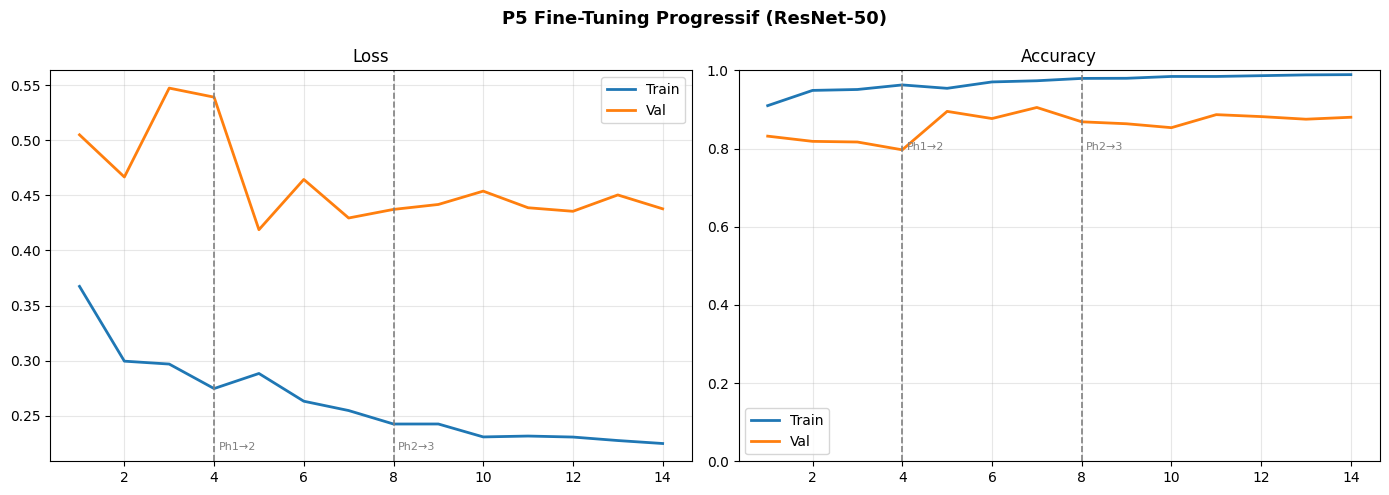


[ResNet-50+FineTuning] Test Acc=0.5984  Loss=1.1707
              precision    recall  f1-score   support

      normal       0.47      0.95      0.63       136
       theft       0.93      0.40      0.56       240

    accuracy                           0.60       376
   macro avg       0.70      0.67      0.60       376
weighted avg       0.77      0.60      0.59       376



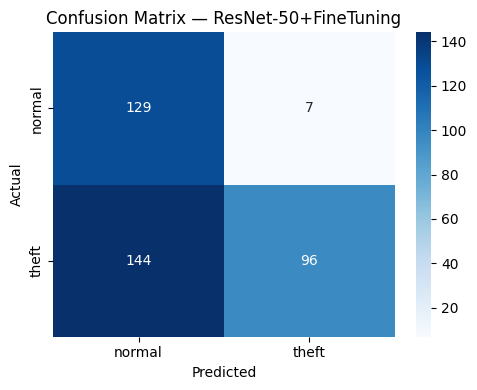

Modele sauvegarde : /kaggle/working/models/resnet50_finetuned.pth  (val_acc=0.9050)

  Sans fine-tuning : 0.5904
  Avec fine-tuning : 0.5984  (↑ 0.0080)


In [ ]:
tl_names = ['ResNet-50', 'EfficientNet-B0', 'MobileNetV3', 'VGG-16']
best_tl   = max(tl_names, key=lambda n: all_results[n]['acc'])
arch_map  = {'ResNet-50':'resnet50', 'EfficientNet-B0':'efficientnet_b0',
             'MobileNetV3':'mobilenet_v3_small', 'VGG-16':'vgg16'}

print(f'Meilleur modele TL : {best_tl}  (test acc={all_results[best_tl]["acc"]:.4f})')
print(f'Progressive unfreeze sur : {best_tl}\n')

ft_model = make_model(arch_map[best_tl], freeze=True)
hist_ft  = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}

def unfreeze_last_n(model, n):
    all_p = list(model.named_parameters())
    for _, p in all_p: p.requires_grad = False
    for _, p in all_p[-n:]: p.requires_grad = True
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot= sum(p.numel() for p in model.parameters())
    print(f'  Trainable : {tr:,} / {tot:,} ({100*tr/tot:.1f}%)')

def train_phase(model, criterion, optimizer, scheduler, n_epochs, phase_name, history):
    best_acc = max(history['val_acc']) if history['val_acc'] else 0.0
    best_w   = copy.deepcopy(model.state_dict())
    for epoch in range(n_epochs):
        t0 = time.time()
        model.train()
        tr_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            tr_loss += loss.item()*imgs.size(0)
            correct += (out.argmax(1)==labels).sum().item()
            total   += labels.size(0)
        tr_loss /= total; tr_acc = correct/total
        model.eval()
        vl_loss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out      = model(imgs)
                loss     = criterion(out, labels)
                vl_loss += loss.item()*imgs.size(0)
                vc += (out.argmax(1)==labels).sum().item(); vt += labels.size(0)
        vl_loss /= vt; vl_acc = vc/vt
        if scheduler: scheduler.step()
        if vl_acc > best_acc: best_acc=vl_acc; best_w=copy.deepcopy(model.state_dict())
        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
        print(f'  [{phase_name}] {epoch+1:02d}/{n_epochs} | '
              f'Loss {tr_loss:.3f}/{vl_loss:.3f} | '
              f'Acc {tr_acc:.3f}/{vl_acc:.3f} | Best {best_acc:.3f} | {time.time()-t0:.1f}s')
        torch.cuda.empty_cache(); gc.collect()
    model.load_state_dict(best_w)
    return model

print('\n' + '='*55)
print('  PHASE 1 — Head uniquement (backbone gele)')
print('='*55)
unfreeze_last_n(ft_model, 10)
opt1 = optim.Adam(filter(lambda p: p.requires_grad, ft_model.parameters()), lr=3e-4)
sch1 = optim.lr_scheduler.StepLR(opt1, step_size=3, gamma=0.5)
ft_model = train_phase(ft_model, crit_weighted, opt1, sch1, 4, 'Phase1', hist_ft)


print('\n' + '='*55)
print('  PHASE 2 — Derniers blocs (unfreeze partiel)')
print('='*55)
unfreeze_last_n(ft_model, 50)
opt2 = optim.Adam(filter(lambda p: p.requires_grad, ft_model.parameters()), lr=1e-4)
sch2 = optim.lr_scheduler.StepLR(opt2, step_size=3, gamma=0.5)
ft_model = train_phase(ft_model, crit_weighted, opt2, sch2, 4, 'Phase2', hist_ft)


print('\n' + '='*55)
print('  PHASE 3 — Reseau complet (full unfreeze)')
print('='*55)
for p in ft_model.parameters(): p.requires_grad = True
opt3 = optim.Adam(ft_model.parameters(), lr=1e-5, weight_decay=1e-4)
sch3 = optim.lr_scheduler.CosineAnnealingLR(opt3, T_max=6)
ft_model = train_phase(ft_model, crit_weighted, opt3, sch3, 6, 'Phase3', hist_ft)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'P5 Fine-Tuning Progressif ({best_tl})', fontsize=13, fontweight='bold')
epochs = range(1, len(hist_ft['val_acc'])+1)
for ax, (tr_k, vl_k), title in zip(axes,
        [('train_loss','val_loss'),('train_acc','val_acc')], ['Loss','Accuracy']):
    ax.plot(epochs, hist_ft[tr_k], label='Train', linewidth=2)
    ax.plot(epochs, hist_ft[vl_k], label='Val',   linewidth=2)
    for sp, lbl in [(4,'Ph1→2'),(8,'Ph2→3')]:
        ax.axvline(x=sp, color='gray', linestyle='--', linewidth=1.2)
        ax.text(sp+0.1, ax.get_ylim()[0]+0.01, lbl, fontsize=8, color='gray')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    if title=='Accuracy': ax.set_ylim(0,1)
plt.tight_layout(); plt.show()

result_ft = evaluate_model(ft_model, test_loader, label=f'{best_tl}+FineTuning')
save_model(ft_model, f'{arch_map[best_tl]}_finetuned', hist_ft)

all_models[f'{best_tl}+FT']    = ft_model
all_histories[f'{best_tl}+FT'] = hist_ft
all_results[f'{best_tl}+FT']   = result_ft

print(f'\n  Sans fine-tuning : {all_results[best_tl]["acc"]:.4f}')
print(f'  Avec fine-tuning : {result_ft["acc"]:.4f}  '
      f'({"↑" if result_ft["acc"] > all_results[best_tl]["acc"] else "↓"} '
      f'{abs(result_ft["acc"]-all_results[best_tl]["acc"]):.4f})')

---
## 13. 📊 Comparaison Finale


  Modele                       Test Acc  Test Loss   Best Val
  ResNet-50+FT                   0.5984     1.1707     0.9050  BEST
  ResNet-50                      0.5904     0.7215     0.8833
  EfficientNet-B0                0.5878     1.1601     0.6850
  MobileNetV3                    0.5824     0.7283     0.8217
  Baseline-CNN                   0.5718     1.1637     0.8033
  VGG-16                         0.5665     1.1150     0.9083


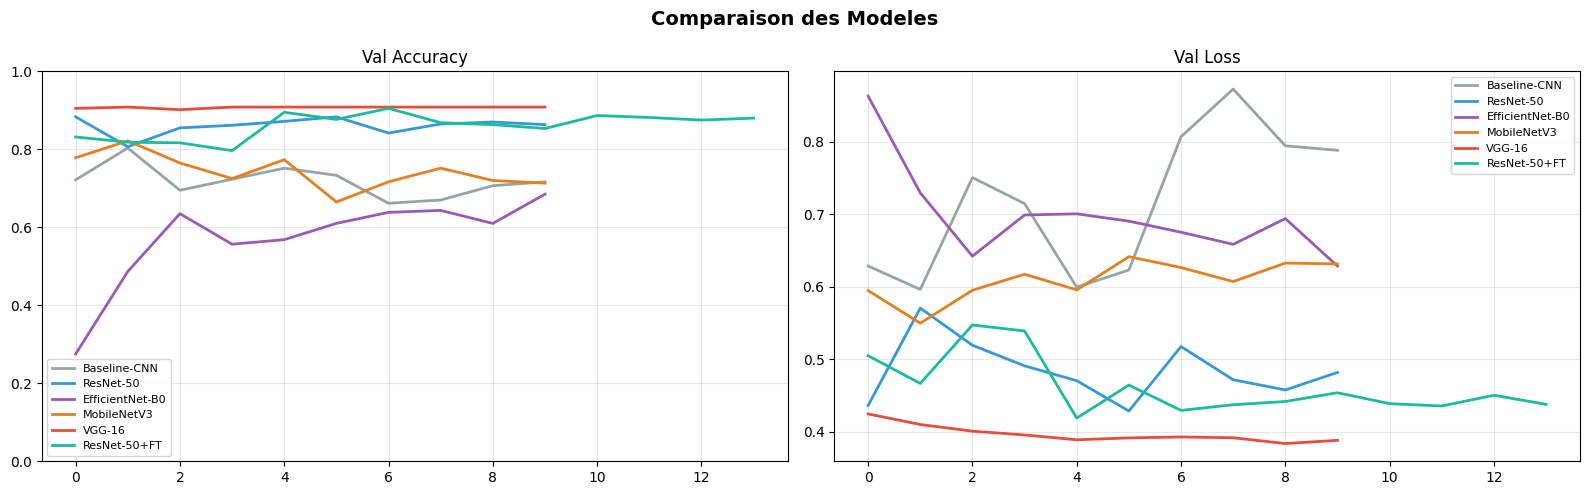

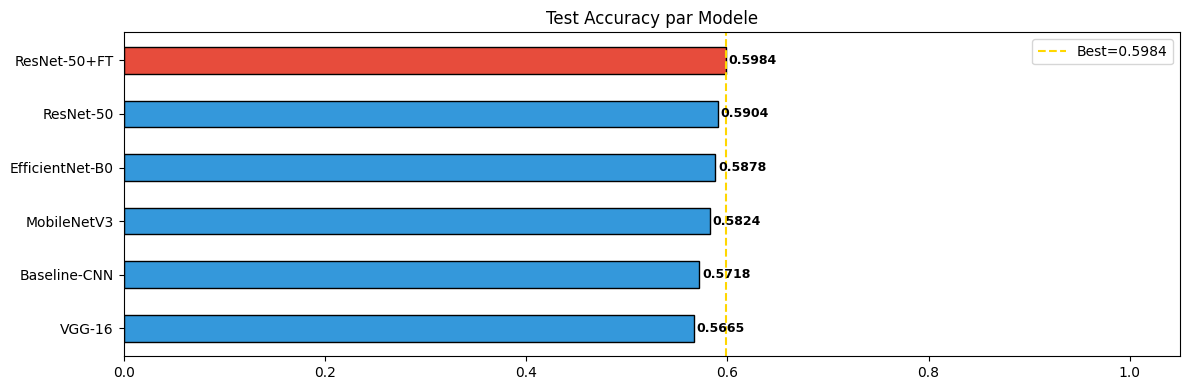

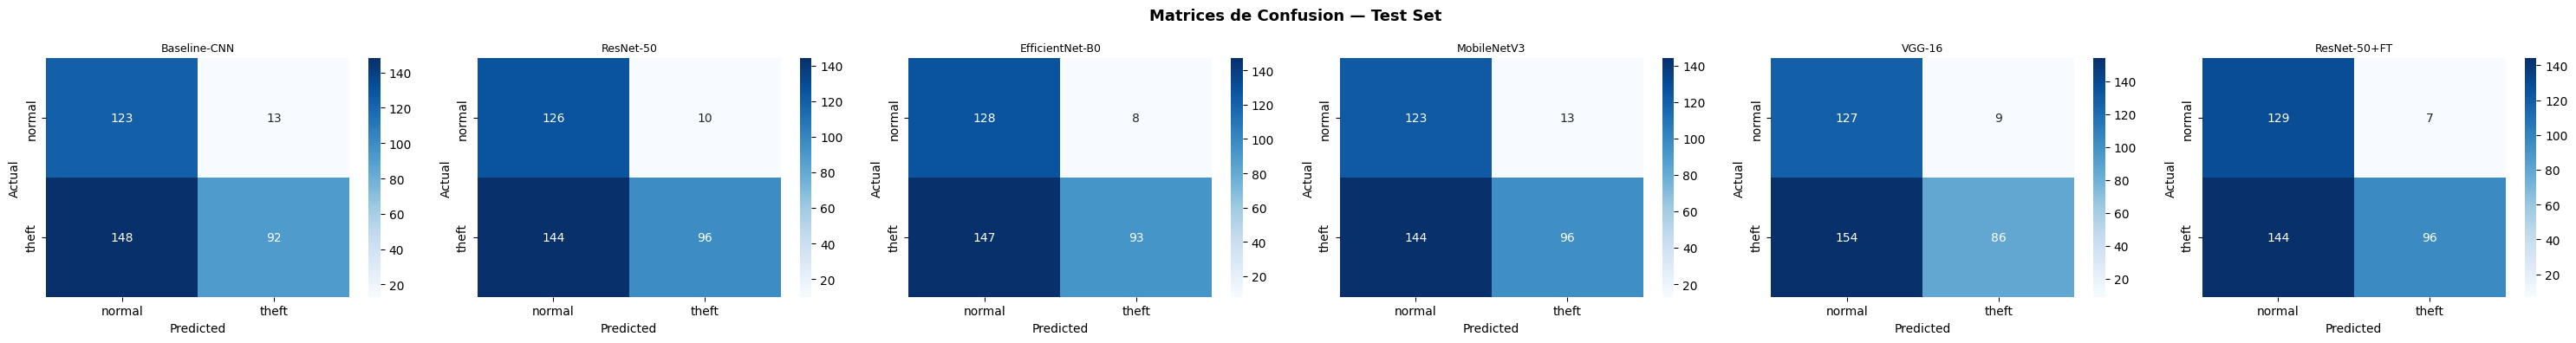


Classification Report — ResNet-50+FT (MEILLEUR)

              precision    recall  f1-score   support

      normal       0.47      0.95      0.63       136
       theft       0.93      0.40      0.56       240

    accuracy                           0.60       376
   macro avg       0.70      0.67      0.60       376
weighted avg       0.77      0.60      0.59       376



In [ ]:
print('\n' + '='*65)
print(f'  {"Modele":<26} {"Test Acc":>10} {"Test Loss":>10} {"Best Val":>10}')
print('='*65)
best_acc_g = max(r['acc'] for r in all_results.values())
for name, r in sorted(all_results.items(), key=lambda x: -x[1]['acc']):
    best_val = max(all_histories[name]['val_acc'])
    marker   = '  BEST' if r['acc'] == best_acc_g else ''
    print(f'  {name:<26} {r["acc"]:>10.4f} {r["loss"]:>10.4f} {best_val:>10.4f}{marker}')
print('='*65)


colors = ['#95A5A6','#3498DB','#9B59B6','#E67E22','#E74C3C','#1ABC9C']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparaison des Modeles', fontsize=14, fontweight='bold')
for (name, hist), c in zip(all_histories.items(), colors):
    axes[0].plot(hist['val_acc'],  label=name, color=c, linewidth=2)
    axes[1].plot(hist['val_loss'], label=name, color=c, linewidth=2)
for ax, title in zip(axes, ['Val Accuracy','Val Loss']):
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylim(0,1)
plt.tight_layout(); plt.show()


names_s = sorted(all_results.keys(), key=lambda n: all_results[n]['acc'])
accs_s  = [all_results[n]['acc'] for n in names_s]
cols_s  = ['#E74C3C' if a==best_acc_g else '#3498DB' for a in accs_s]
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(names_s, accs_s, color=cols_s, edgecolor='black', height=0.5)
for bar, acc in zip(bars, accs_s):
    ax.text(acc+0.003, bar.get_y()+bar.get_height()/2,
            f'{acc:.4f}', va='center', fontweight='bold', fontsize=9)
ax.set_xlim(0, 1.05)
ax.axvline(x=best_acc_g, color='gold', linestyle='--', linewidth=1.5,
           label=f'Best={best_acc_g:.4f}')
ax.set_title('Test Accuracy par Modele')
ax.legend(); plt.tight_layout(); plt.show()


n   = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
fig.suptitle('Matrices de Confusion — Test Set', fontsize=13, fontweight='bold')
for ax, (name, r), c in zip(axes, all_results.items(), colors):
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()


best_name = max(all_results, key=lambda n: all_results[n]['acc'])
print(f'\nClassification Report — {best_name} (MEILLEUR)\n')
print(classification_report(all_results[best_name]['labels'],
                             all_results[best_name]['preds'],
                             target_names=CLASS_NAMES))

---
## 14. 🔎 Évaluation Complète & Sauvegarde

In [15]:
from google.colab import drive

import os
print("Modèles disponibles :")
for f in os.listdir('/kaggle/working/models/'):
    size = os.path.getsize(f'/kaggle/working/models/{f}') / 1e6
    print(f"  {f:30s} {size:.1f} MB")

Modèles disponibles :
  resnet50_finetuned.pth         95.4 MB
  efficientnet_b0.pth            17.0 MB
  vgg16.pth                      539.2 MB
  baseline_cnn.pth               10.2 MB
  mobilenet_v3.pth               6.7 MB
  resnet50.pth                   95.4 MB


In [ ]:
from IPython.display import FileLink
import os

for f in os.listdir('/kaggle/working/models/'):
    print(f"/kaggle/working/models/{f}")

/kaggle/working/models/resnet50_finetuned.pth
/kaggle/working/models/efficientnet_b0.pth
/kaggle/working/models/vgg16.pth
/kaggle/working/models/baseline_cnn.pth
/kaggle/working/models/mobilenet_v3.pth
/kaggle/working/models/resnet50.pth


In [17]:
import os, zipfile
from IPython.display import display, FileLink

# Zipper tous les modèles en UN seul fichier
zip_path = '/kaggle/working/models_theft_detection.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in os.listdir('/kaggle/working/models/'):
        if f.endswith('.pth') and 'vgg' not in f:  # exclure vgg16 (539MB)
            src = f'/kaggle/working/models/{f}'
            zf.write(src, f)
            size = os.path.getsize(src)/1e6
            print(f'  ✅ {f:40s} {size:.1f} MB ajouté')

zip_size = os.path.getsize(zip_path)/1e6
print(f'\n📦 ZIP créé : {zip_size:.1f} MB')
display(FileLink('models_theft_detection.zip',
                 result_html_prefix='⬇️ TÉLÉCHARGER TOUS LES MODÈLES : '))

  ✅ resnet50_finetuned.pth                   95.4 MB ajouté
  ✅ efficientnet_b0.pth                      17.0 MB ajouté
  ✅ baseline_cnn.pth                         10.2 MB ajouté
  ✅ mobilenet_v3.pth                         6.7 MB ajouté
  ✅ resnet50.pth                             95.4 MB ajouté

📦 ZIP créé : 208.3 MB


/kaggle/working/models_theft_detection.zip

---
## 📝 Récapitulatif Final

| Critère | Détail |
|---------|--------|
| **Problème** | Classification binaire : theft / normal |
| **Dataset** | Fusion ~9 747 images (train/valid/test) |
| **Mapping** | class_id 0→normal, 1,2,3→theft |
| **Balance (P4)** | WeightedRandomSampler + CrossEntropy class weights |
| **Modèles** | SimpleCNN, ResNet-50, EfficientNet-B0, MobileNetV3, VGG-16 |
| **Fine-Tuning (P5)** | Progressive unfreeze : Head → Partiel → Full |
| **Loss** | CrossEntropy + class weights + label_smoothing=0.1 |
| **Anti-overfit** | Dropout, BatchNorm, Augmentation |

---

### 🎓 Points clés pour la soutenance

**Gradient vanishing :** dans un CNN profond, le gradient s'atténue → ResNet résout ce problème avec des **skip connections**.

**P4 Balance :** WeightedRandomSampler rééquilibre l'échantillonnage, class weights pénalisent davantage les erreurs sur la classe minoritaire.

**P5 Fine-Tuning progressif :**
- Phase 1 : seul le head s'adapte au domaine (vol/normal)
- Phase 2 : les dernières couches affinent les features haut niveau
- Phase 3 : tout le réseau se spécialise avec un lr très faible

**AdamW vs Adam :** découple le weight decay du moment → meilleure régularisation.

**Interprétation des courbes :**
- Gap train/val > 10% → surapprentissage → augmenter dropout
- Val loss qui remonte → early stopping